Importing libraries

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Load CIFAR10 Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

100%|██████████| 170M/170M [00:03<00:00, 54.9MB/s]


Sparse Encoder Model

In [3]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

Hyperparameters

In [4]:
model = SparseAutoencoder()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20

Training loop

In [5]:
for epoch in range(num_epochs):

    for images, _ in train_loader:

        images = images.view(images.size(0), -1)

        outputs, encoded = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0276
Epoch 2, Loss: 0.0253
Epoch 3, Loss: 0.0207
Epoch 4, Loss: 0.0184
Epoch 5, Loss: 0.0175
Epoch 6, Loss: 0.0167
Epoch 7, Loss: 0.0160
Epoch 8, Loss: 0.0149
Epoch 9, Loss: 0.0136
Epoch 10, Loss: 0.0143
Epoch 11, Loss: 0.0139
Epoch 12, Loss: 0.0135
Epoch 13, Loss: 0.0137
Epoch 14, Loss: 0.0130
Epoch 15, Loss: 0.0138
Epoch 16, Loss: 0.0126
Epoch 17, Loss: 0.0117
Epoch 18, Loss: 0.0126
Epoch 19, Loss: 0.0121
Epoch 20, Loss: 0.0118


Reconstruction Visualization

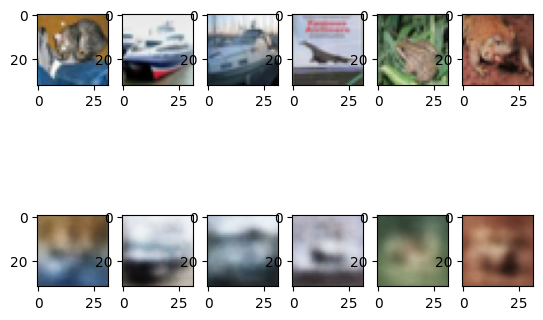

In [6]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.view(images.size(0), -1)

outputs, _ = model(images)

images = images.view(-1,3,32,32)
outputs = outputs.view(-1,3,32,32)

fig, axes = plt.subplots(2,6)

for i in range(6):
    axes[0,i].imshow(images[i].permute(1,2,0))
    axes[1,i].imshow(outputs[i].detach().permute(1,2,0))

plt.show()

#Result

The Sparse Autoencoder was successfully trained on the CIFAR-10 dataset.
The model learned compressed feature representations and was able to reconstruct input images with reasonable accuracy.
#Conclusion
This experiment demonstrated how Sparse Autoencoders can learn meaningful representations from image data. By enforcing sparsity constraints, the model focuses on extracting essential features rather than simply copying the input.